# Circuit Capacity Model Demo

This notebook demonstrates the current circuit-capacity model used to estimate how many circuits or loops a battery can complete at a given SOH level.

The model has two parts:

- a calibration curve that maps SOH to estimated SOC consumed per circuit
- a linear regression that estimates SOC depletion rate under typical operating conditions

The notebook does not retrain anything. It reads the saved artifacts under `ml_workspace/circuit_capacity/output` and visualizes the current behavior.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def bootstrap_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "ml_workspace").exists() and (candidate / "data").exists():
            return candidate
    raise RuntimeError("Could not locate repo root")


REPO_ROOT = bootstrap_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ml_workspace.circuit_capacity.predict_circuits import build_capacity_sweep, load_capacity_artifacts

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

OUTPUT_ROOT = REPO_ROOT / "ml_workspace" / "circuit_capacity" / "output"
MODEL_PATH = OUTPUT_ROOT / "circuit_model.json"
RATE_MODEL_PATH = OUTPUT_ROOT / "soc_rate_model.joblib"
METRICS_PATH = OUTPUT_ROOT / "soc_rate_model_metrics.json"
CALIBRATION_PATH = OUTPUT_ROOT / "circuit_calibration.csv"

artifacts = load_capacity_artifacts(model_path=MODEL_PATH, rate_model_path=RATE_MODEL_PATH)
metrics = json.loads(METRICS_PATH.read_text())
calibration_df = pd.read_csv(CALIBRATION_PATH)
feature_defaults = {k: v for k, v in artifacts.feature_medians.items() if k != "latent_soh_smooth_pct"}

print("Repo root:", REPO_ROOT)
print("Output root:", OUTPUT_ROOT)
print("Planes in calibration:", sorted(artifacts.model_meta.get("k_plane", {})))


Repo root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane
Output root: /Users/benfogerty/Desktop/EPlaneCapstone/CapstoneEPlane/ml_workspace/circuit_capacity/output
Planes in calibration: ['166', '192']


## Artifact Summary

The calibration file stores the fitted plane or battery scaling factors. The metrics JSON reports how well the SOC-rate regression predicts SOC depletion rate on train, validation, test, and out-of-distribution data.

In [2]:
metrics_df = pd.DataFrame(metrics).T.reset_index().rename(columns={"index": "split"})
metrics_df[["mae", "rmse", "r2"]] = metrics_df[["mae", "rmse", "r2"]].astype(float)
coef_df = pd.DataFrame(
    {
        "feature": artifacts.feature_cols,
        "coefficient": artifacts.rate_model.coef_,
        "abs_coefficient": np.abs(artifacts.rate_model.coef_),
    }
).sort_values("abs_coefficient", ascending=False)

display(metrics_df.round(4))
display(calibration_df)
display(pd.DataFrame([artifacts.model_meta]))
display(coef_df.round(6))


,split,mae,rmse,r2
0,train_metrics,0.1276,0.1869,0.6828
1,valid_metrics,0.0926,0.1211,0.7020
2,test_metrics,0.1921,0.2629,0.5553
3,ood_metrics,0.1963,0.2417,0.5414


,plane_id,battery_id,k_plane_batt,n_flights
0,166,1,0.80,189
1,166,2,0.80,189
2,192,1,0.64,20
3,192,2,0.84,20


,k_plane,default_k,poh_soh_grid,poh_circuit_soc,reserve_soc_pct
0,"{'166': 0.7999999999999999, '192': 0.74}",1.0,"[0.0, 20.0, 40.0, 60.0, 80.0, 100.0]","[20.0, 16.0, 13.0, 12.0, 10.0, 9.0]",30.0


,feature,coefficient,abs_coefficient
6,soc_max_pct,0.015044,0.015044
5,soc_min_pct,-0.012565,0.012565
2,p95_abs_current_a,0.006506,0.006506
3,avg_cell_temp_mean_c,0.004923,0.004923
0,latent_soh_smooth_pct,-0.002897,0.002897
4,voltage_mean_v,-0.002429,0.002429
1,current_abs_mean_a,0.002073,0.002073
7,p95_abs_dcurrent_a_per_s,0.000597,0.000597
8,kalman_coulomb_gap_mean_pct,0.000042,0.000042


## SOC Consumed Per Circuit vs SOH

This is the direct calibration curve. Lower values are better because they imply each loop uses less SOC.

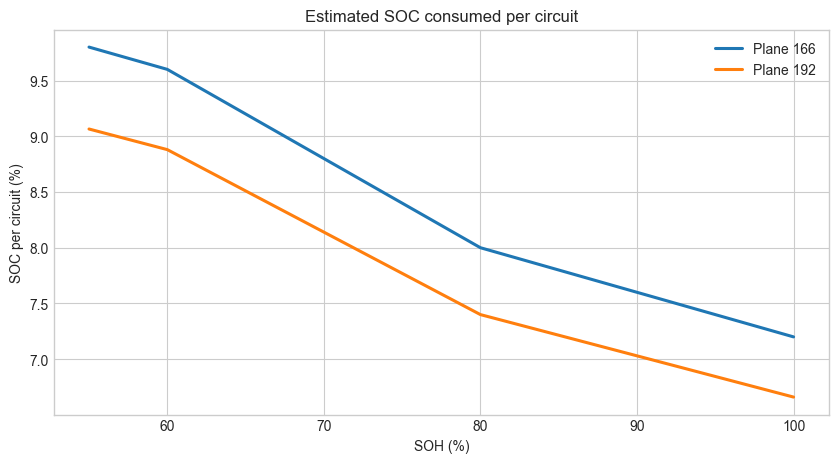

In [3]:
soh_values = np.linspace(55.0, 100.0, 46)
plane_ids = sorted(artifacts.model_meta.get("k_plane", {}))

fig, ax = plt.subplots(figsize=(10, 5))
for plane_id in plane_ids:
    sweep_df = build_capacity_sweep(
        soh_values=soh_values,
        plane_id=plane_id,
        soc_start_pct=100.0,
        feature_inputs=feature_defaults,
        artifacts=artifacts,
    )
    ax.plot(sweep_df["soh_pct"], sweep_df["soc_per_circuit_pct"], linewidth=2.2, label=f"Plane {plane_id}")

ax.set_title("Estimated SOC consumed per circuit")
ax.set_xlabel("SOH (%)")
ax.set_ylabel("SOC per circuit (%)")
ax.legend(loc="best")
plt.show()


## Maximum Circuits vs SOH

This converts the SOC-per-circuit estimate into a maximum loop count after accounting for the reserve SOC floor in the saved model.

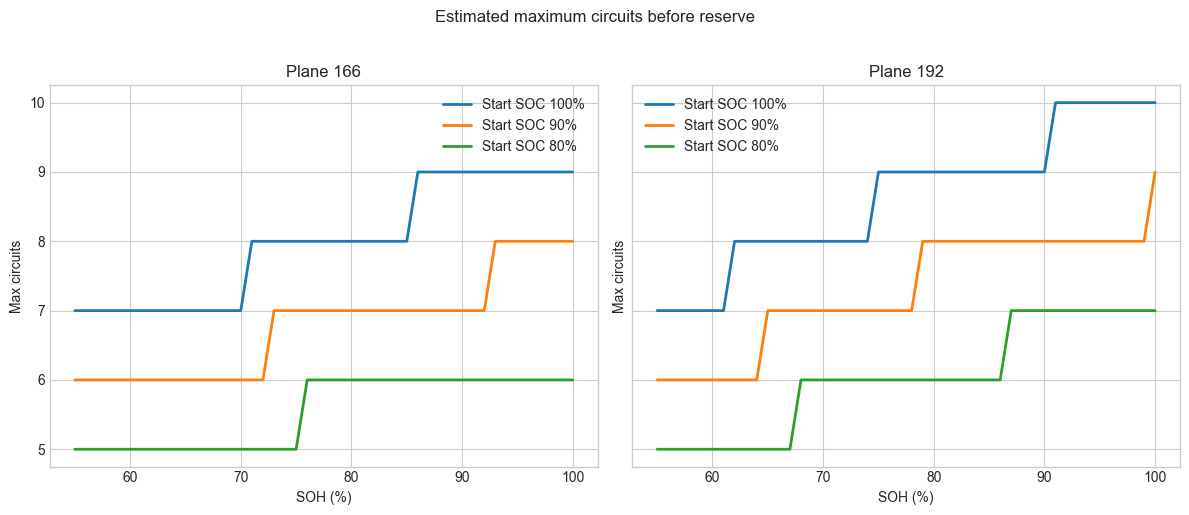

In [4]:
start_soc_levels = [100.0, 90.0, 80.0]
fig, axes = plt.subplots(1, max(len(plane_ids), 1), figsize=(6 * max(len(plane_ids), 1), 5), sharey=True)
axes = np.atleast_1d(axes)

for ax, plane_id in zip(axes, plane_ids):
    for soc_start in start_soc_levels:
        sweep_df = build_capacity_sweep(
            soh_values=soh_values,
            plane_id=plane_id,
            soc_start_pct=soc_start,
            feature_inputs=feature_defaults,
            artifacts=artifacts,
        )
        ax.plot(sweep_df["soh_pct"], sweep_df["circuits_max"], linewidth=2.0, label=f"Start SOC {soc_start:.0f}%")
    ax.set_title(f"Plane {plane_id}")
    ax.set_xlabel("SOH (%)")
    ax.set_ylabel("Max circuits")
    ax.legend(loc="best")

fig.suptitle("Estimated maximum circuits before reserve", y=1.02)
fig.tight_layout()
plt.show()


## Example Planning Table

This table is the practical planning view: given a plane, SOH, and starting SOC, how many loops are available and what depletion rate does the regression expect under median conditions.

In [5]:
scenario_soh = [100.0, 95.0, 90.0, 85.0, 80.0, 75.0, 70.0]
scenario_rows = []
for plane_id in plane_ids:
    for soc_start in [100.0, 90.0]:
        sweep_df = build_capacity_sweep(
            soh_values=scenario_soh,
            plane_id=plane_id,
            soc_start_pct=soc_start,
            feature_inputs=feature_defaults,
            artifacts=artifacts,
        )
        scenario_rows.append(sweep_df)

scenario_df = pd.concat(scenario_rows, ignore_index=True)
display(
    scenario_df[
        [
            "plane_id",
            "soh_pct",
            "soc_start_pct",
            "usable_soc_window_pct",
            "soc_per_circuit_pct",
            "circuits_max",
            "soc_rate_pct_per_min",
        ]
    ].round(3)
)


,plane_id,soh_pct,soc_start_pct,usable_soc_window_pct,soc_per_circuit_pct,circuits_max,soc_rate_pct_per_min
0,166,100.0,100.0,70.0,7.200,9,1.174
1,166,95.0,100.0,70.0,7.400,9,1.189
2,166,90.0,100.0,70.0,7.600,9,1.203
3,166,85.0,100.0,70.0,7.800,8,1.218
4,166,80.0,100.0,70.0,8.000,8,1.232
5,166,75.0,100.0,70.0,8.400,8,1.247
6,166,70.0,100.0,70.0,8.800,7,1.261
7,166,100.0,90.0,60.0,7.200,8,1.174
8,166,95.0,90.0,60.0,7.400,8,1.189
9,166,90.0,90.0,60.0,7.600,7,1.203


## SOC-Rate Model Interpretation

The regression does not change the circuit count directly. It estimates how quickly SOC is consumed during a representative flight, which is useful for understanding how current, temperature, voltage, and SOC window influence loop feasibility.

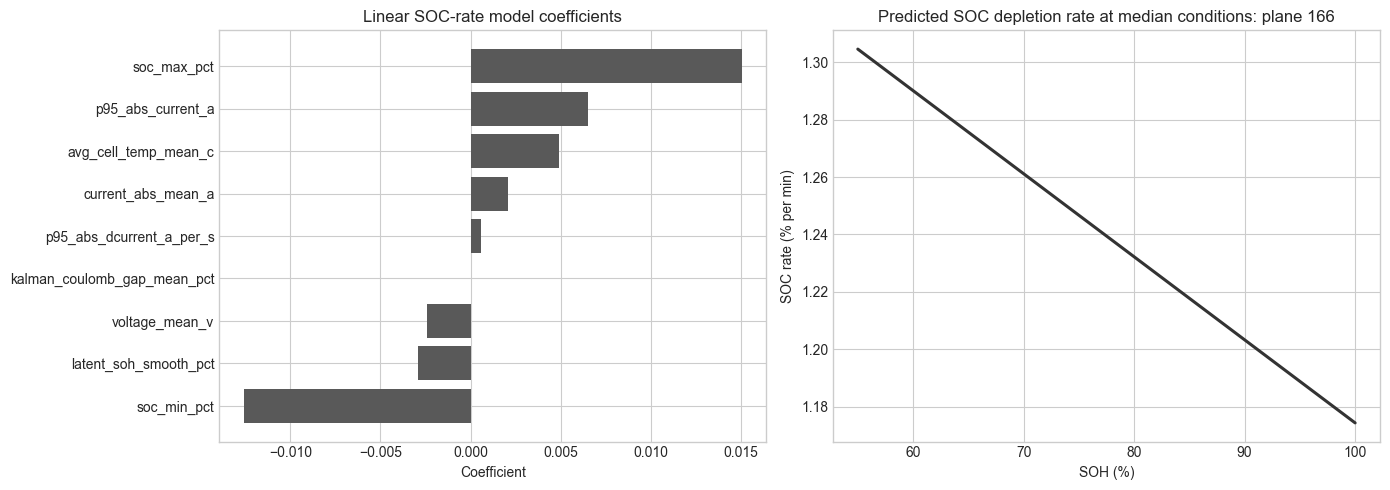

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

coef_plot_df = coef_df.sort_values("coefficient")
axes[0].barh(coef_plot_df["feature"], coef_plot_df["coefficient"], color="0.35")
axes[0].set_title("Linear SOC-rate model coefficients")
axes[0].set_xlabel("Coefficient")

rate_curve_df = build_capacity_sweep(
    soh_values=soh_values,
    plane_id=plane_ids[0],
    soc_start_pct=100.0,
    feature_inputs=feature_defaults,
    artifacts=artifacts,
)
axes[1].plot(rate_curve_df["soh_pct"], rate_curve_df["soc_rate_pct_per_min"], linewidth=2.2, color="0.2")
axes[1].set_title(f"Predicted SOC depletion rate at median conditions: plane {plane_ids[0]}")
axes[1].set_xlabel("SOH (%)")
axes[1].set_ylabel("SOC rate (% per min)")

fig.tight_layout()
plt.show()
